CLASSIFICATION VS REGRESSION


In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression,LogisticRegression
X=np.array([[1],[2],[3],[4],[5],[6],[7],[8]])
y_reg=np.array([30,40,45,55,65,70,80,90])
y_class=np.array([0,0,0,0,1,1,1,1])
lin=LinearRegression()
lin.fit(X,y_reg)
print('Regression Outputs',lin.predict([[5.5]]))
log=LogisticRegression()
log.fit(X,y_class)
print('Classification Outputs',log.predict([[4.7]]))
print('Probability Outputs:',log.predict_proba([[5.5]]))

Regression Outputs [67.76785714]
Classification Outputs [1]
Probability Outputs: [[0.2368932 0.7631068]]


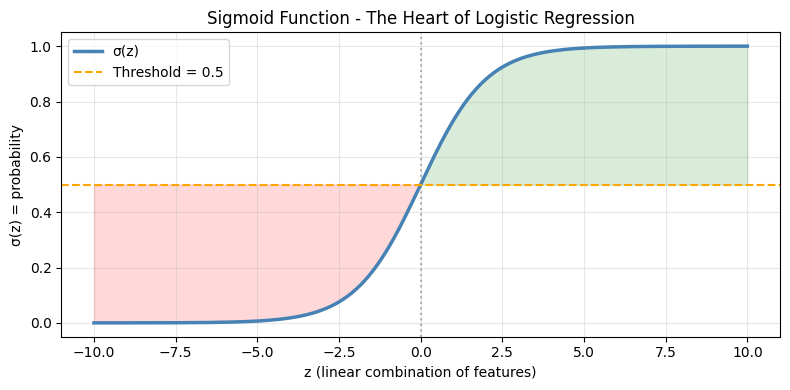

sigmoid(0) = 0.5000
sigmoid(5) = 0.9933
sigmoid(-5) = 0.0067


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
def sigmoid(z):
    return 1 / (1 + np.exp(-z))
z = np.linspace(-10, 10, 300)
prob = sigmoid(z)
plt.figure(figsize=(8, 4))
plt.plot(z, prob, color='steelblue', linewidth=2.5, label='σ(z)')
plt.axhline(y=0.5, color='orange', linestyle='--', label='Threshold = 0.5')
plt.axvline(x=0, color='gray', linestyle=':', alpha=0.6)
plt.fill_between(z, prob, 0.5,where=(prob > 0.5),alpha=0.15,color='green')
plt.fill_between(z, prob, 0.5,where=(prob < 0.5),alpha=0.15,color='red')
plt.xlabel('z (linear combination of features)')
plt.ylabel('σ(z) = probability')
plt.title('Sigmoid Function - The Heart of Logistic Regression')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f"sigmoid(0) = {sigmoid(0):.4f}")
print(f"sigmoid(5) = {sigmoid(5):.4f}")
print(f"sigmoid(-5) = {sigmoid(-5):.4f}")

In [ ]:

from sklearn import linear_model
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score,recall_score,f1_score
from sklearn.model_selection import train_test_split
x,y=make_classification(n_samples=500,n_features=5,
                        weights=[0.7,0.3],random_state=42)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
model=LogisticRegression();
model.fit(x_train,y_train)
probs=model.predict_proba(x_test)[:,1]


print(f'{'threshold':>10}{'precision':>10}{'recall':>8}{'f1':>66}')
print('_'*45)
for threshold in[0.2,0.3,0.4,0.5,0.6,0.7,0.8]:
  preds=(probs>=threshold).astyp   e(int)
  precision=precision_score(y_test,preds,zero_division=0)
  recall=recall_score(y_test,preds)
  f1=f1_score(y_test,preds,zero_division=0)
  print(f'{threshold:>10.1f}{precision:>10.3f}{recall:>8.3f}{f1:>6.3f}')

 threshold precision  recall                                                                f1
_____________________________________________
       0.2     0.696   0.941 0.800
       0.3     0.762   0.941 0.842
       0.4     0.882   0.882 0.882
       0.5     0.882   0.882 0.882
       0.6     0.903   0.824 0.862
       0.7     0.903   0.824 0.862
       0.8     0.958   0.676 0.793


TP:5,TN:4,FP:3,FN:3
Accuracy:0.6
Precision:0.625
Recall:0.625


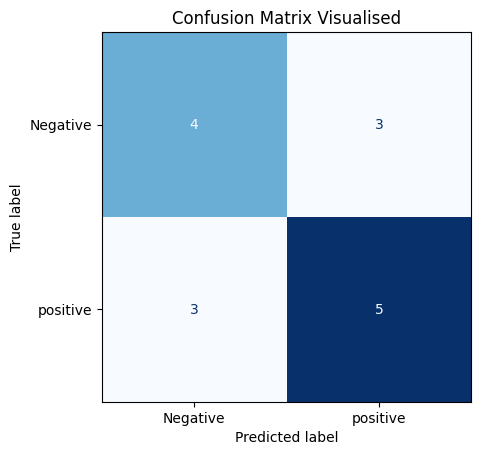

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt
y_true=[1,1,1,1,1, 0,0,0,0,0, 1,0,1,0,1]
y_pred=[1,1,1,0,0, 0,0,0,1,1, 1,0,0,1,1]
y_true=np.array(y_true)
y_pred=np.array(y_pred)
TP=((y_pred==1) & (y_true==1)).sum()
TN=((y_pred==0) & (y_true==0)).sum()
FP=((y_pred==1) & (y_true==0)).sum()
FN=((y_pred==0) & (y_true==1)).sum()
print(f'TP:{TP},TN:{TN},FP:{FP},FN:{FN}')
print(f'Accuracy:{(TP+TN)/(TP+TN+FP+FN)}')
print(f'Precision:{TP/(TP+FP)}')
print(f'Recall:{TP/(TP+FN)}')
cm=confusion_matrix(y_true,y_pred)
disp=ConfusionMatrixDisplay(cm,display_labels=['Negative','positive'])
disp.plot(cmap='Blues',colorbar=False)
plt.title('Confusion Matrix Visualised');plt.show()

In [ ]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.model_selection import train_test_split

X_bal, y_bal = make_classification(
    n_samples=1000,
    weights=[0.5, 0.5],
    random_state=1
)

X_imb, y_imb = make_classification(
    n_samples=1000,
    weights=[0.99, 0.01],
    random_state=1
)

def evaluate(X, y, label):
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print(f"\n=== {label} ===")
    print(f"Accuracy : {acc:.2%} {'MISLEADING!' if f1 < 0.5 else 'OK'}")
    print(f"F1 Score : {f1:.2%} Real Performance")
    print(classification_report(y_test, y_pred, zero_division=0))

evaluate(X_bal, y_bal, "Balanced Dataset")
evaluate(X_imb, y_imb, "Imbalanced Dataset")

X_train, X_test, y_train, y_test = train_test_split(
    X_imb,
    y_imb,
    test_size=0.2,
    random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

model_fixed = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)

model_fixed.fit(X_train, y_train)

y_pred_fixed = model_fixed.predict(X_test)

print("\n=== Original Model ===")
print(classification_report(y_test, y_pred, zero_division=0))

print("\n=== After class_weight='balanced' ===")
print(classification_report(y_test, y_pred_fixed, zero_division=0))


=== Balanced Dataset ===
Accuracy : 80.50% OK
F1 Score : 80.00% Real Performance
              precision    recall  f1-score   support

           0       0.84      0.78      0.81       106
           1       0.77      0.83      0.80        94

    accuracy                           0.81       200
   macro avg       0.81      0.81      0.80       200
weighted avg       0.81      0.81      0.81       200


=== Imbalanced Dataset ===
Accuracy : 97.50% MISLEADING!
F1 Score : 0.00% Real Performance
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       196
           1       0.00      0.00      0.00         4

    accuracy                           0.97       200
   macro avg       0.49      0.50      0.49       200
weighted avg       0.96      0.97      0.97       200


=== Original Model ===
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       196
           1       0.00      0.00      

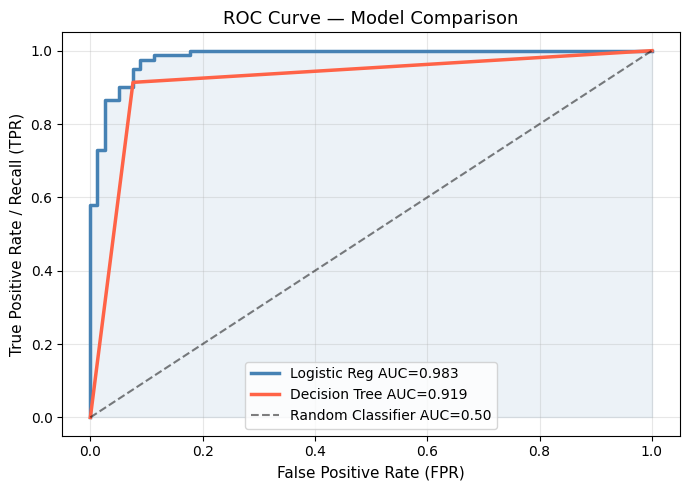

Logistic Regression AUC: 0.9833
Decision Tree AUC: 0.9188
Higher AUC = better model at separating classes


In [ ]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve,roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
X,y=make_classification(n_samples=800,n_features=10,random_state=42)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
lr=LogisticRegression().fit(X_train_scaled,y_train)
prob_lr=lr.predict_proba(X_test_scaled)[:,1]
dt=DecisionTreeClassifier().fit(X_train_scaled,y_train)
prob_dt=dt.predict_proba(X_test_scaled)[:,1]
fpr_lr,tpr_lr,_=roc_curve(y_test,prob_lr)
fpr_dt,tpr_dt,_=roc_curve(y_test,prob_dt)
auc_lr=roc_auc_score(y_test,prob_lr)
auc_dt=roc_auc_score(y_test,prob_dt)
plt.figure(figsize=(7, 5))
plt.plot(fpr_lr, tpr_lr, lw=2.5, color='steelblue', label=f'Logistic Reg AUC={auc_lr:.3f}')
plt.plot(fpr_dt, tpr_dt, lw=2.5, color='tomato', label=f'Decision Tree AUC={auc_dt:.3f}')
plt.plot([0,1],[0,1], 'k--', alpha=0.5, label='Random Classifier AUC=0.50')
plt.fill_between(fpr_lr, tpr_lr, alpha=0.1, color='steelblue')
plt.xlabel('False Positive Rate (FPR)', fontsize=11)
plt.ylabel('True Positive Rate / Recall (TPR)', fontsize=11)
plt.title('ROC Curve — Model Comparison', fontsize=13)
plt.legend(fontsize=10); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f'Logistic Regression AUC: {auc_lr:.4f}')
print(f'Decision Tree AUC: {auc_dt:.4f}')
print('Higher AUC = better model at separating classes')

LAB

--2026-06-01 10:09:31--  https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 23873 (23K) [text/plain]
Saving to: ‘diabetes.csv’

diabetes.csv        100%[===================>]  23.31K  --.-KB/s    in 0.001s  

2026-06-01 10:09:31 (35.8 MB/s) - ‘diabetes.csv’ saved [23873/23873]

(768, 9)
Outcome
0    500
1    268
Name: count, dtype: int64
       Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin     BMI  \
count       768.00   768.00         768.00         768.00   768.00  768.00   
mean          3.85   120.89          69.11          20.54    79.80   31.99   
std           3.37    31.97          19.36          15.95   115.24    7.88   
min           0.00     0.00           0.00       

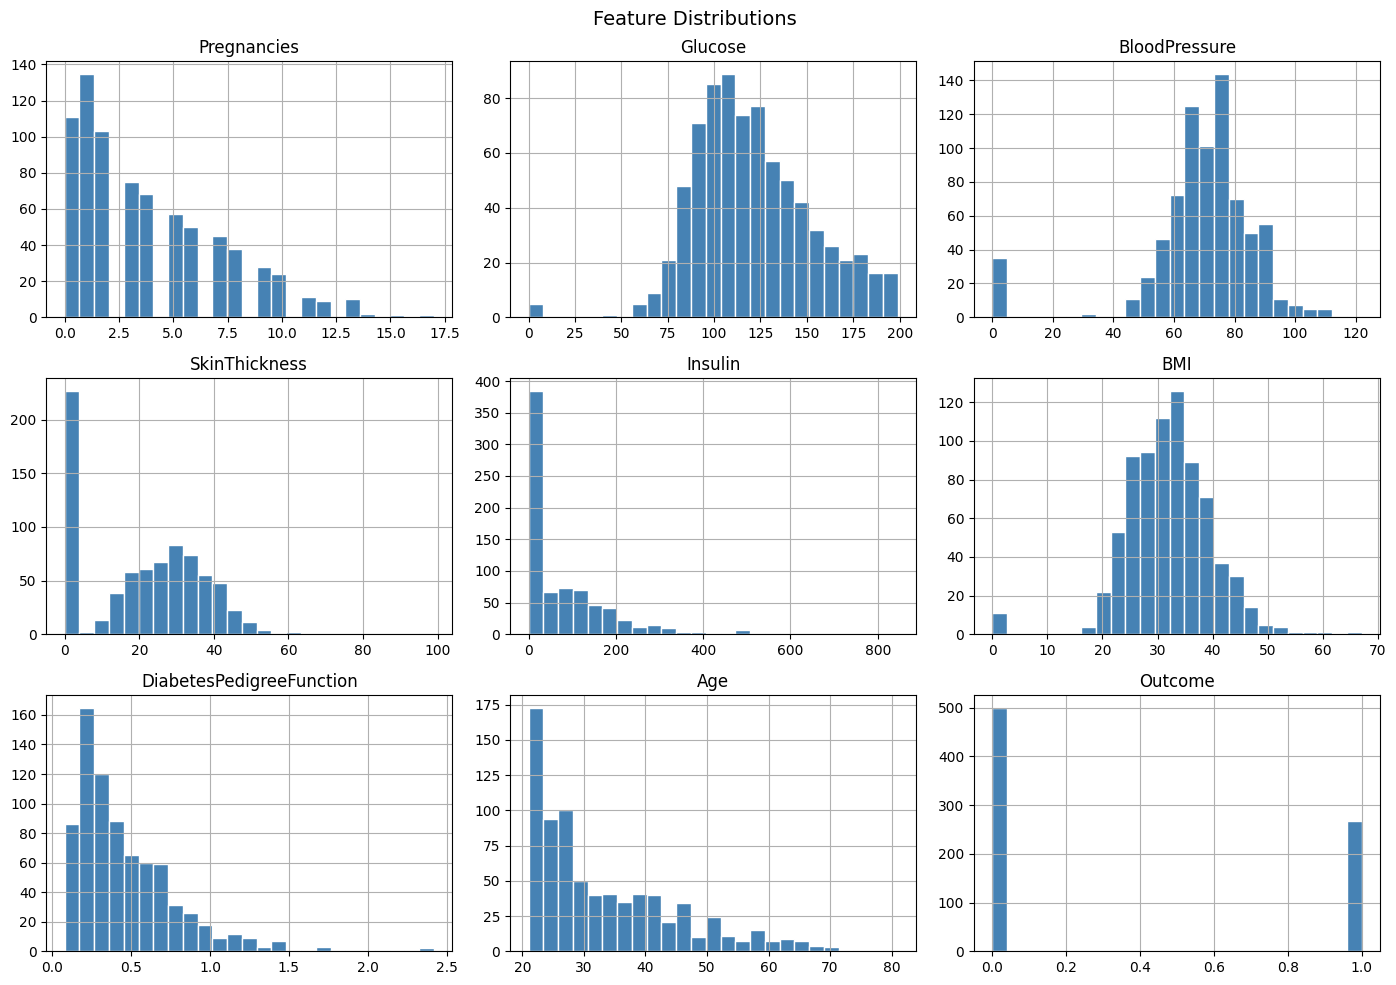

Glucose                  : 5 zeros -> replaced with median 117.0
BloodPressure            : 35 zeros -> replaced with median 72.0
SkinThickness            : 227 zeros -> replaced with median 23.0
Insulin                  : 374 zeros -> replaced with median 31.2
BMI                      : 11 zeros -> replaced with median 32.0

Feature Coefficients
Pregnancies                   : +0.376
Glucose                       : +1.209
BloodPressure                 : -0.054
SkinThickness                 : +0.029
Insulin                       : -0.133
BMI                           : +0.701
DiabetesPedigreeFunction      : +0.245
Age                           : +0.138

Classification Report
              precision    recall  f1-score   support

     Healthy       0.75      0.82      0.78       100
    Diabetic       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70 

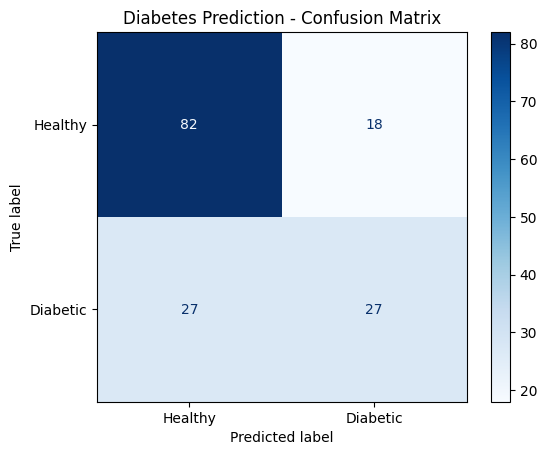

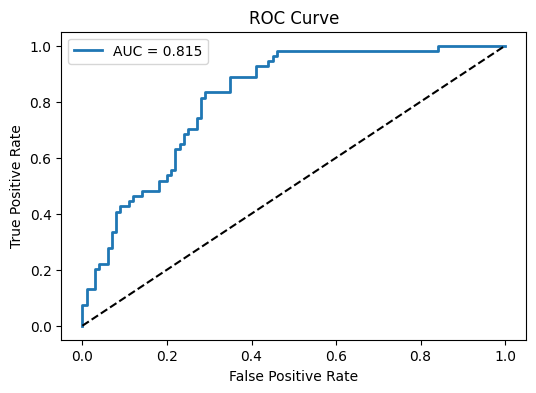


ROC-AUC Score: 0.815

New Patient Prediction
Prediction : Diabetic
Probability : 73.35%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


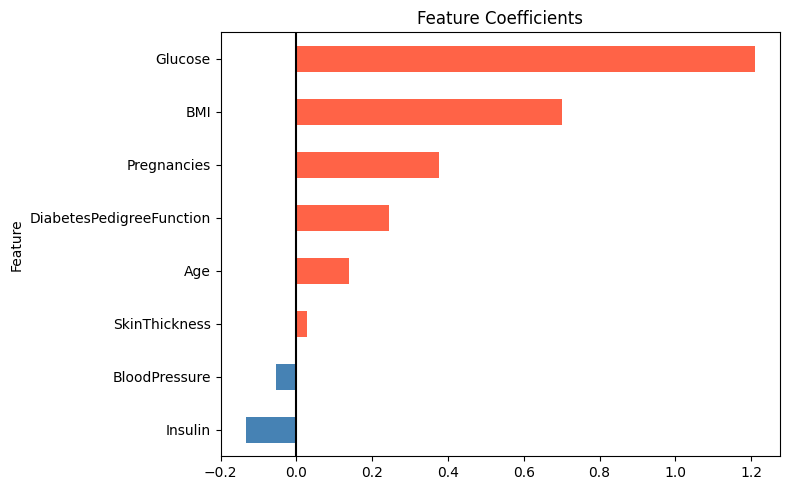

In [ ]:
!wget -O diabetes.csv https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve
df = pd.read_csv("diabetes.csv")
print(df.shape)
print(df["Outcome"].value_counts())
print(df.describe().round(2))
df.hist(bins=25, figsize=(14,10), color="steelblue", edgecolor="white")
plt.suptitle("Feature Distributions", fontsize=14)
plt.tight_layout()
plt.show()
fix_cols = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
for col in fix_cols:
    n = (df[col] == 0).sum()
    df[col] = df[col].replace(0, df[col].median())
    print(f"{col:25s}: {n} zeros -> replaced with median {df[col].median():.1f}")
X = df.drop("Outcome", axis=1)
y = df["Outcome"]
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
print("\nFeature Coefficients")
for name, coef in zip(X.columns, model.coef_[0]):
    print(f"{name:30s}: {coef:+.3f}")
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]
print("\nClassification Report")
print(classification_report(y_test, y_pred, target_names=["Healthy","Diabetic"]))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["Healthy","Diabetic"]).plot(cmap="Blues")
plt.title("Diabetes Prediction - Confusion Matrix")
plt.show()
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
print(f"\nROC-AUC Score: {auc:.3f}")
new_patient = np.array([[6,148,72,35,0,33.6,0.627,50]])
new_scaled = scaler.transform(new_patient)
prediction = model.predict(new_scaled)[0]
probability = model.predict_proba(new_scaled)[0,1]
print("\nNew Patient Prediction")
if prediction == 1:
    print("Prediction : Diabetic")
else:
    print("Prediction : Healthy")
print(f"Probability : {probability:.2%}")
coef_df = pd.DataFrame({"Feature": X.columns,"Coefficient": model.coef_[0]})
coef_df = coef_df.sort_values("Coefficient")
colors = ["tomato" if c > 0 else "steelblue" for c in coef_df["Coefficient"]]
coef_df.plot(kind="barh",x="Feature",y="Coefficient",color=colors,legend=False,figsize=(8,5))
plt.axvline(x=0, color="black")
plt.title("Feature Coefficients")
plt.tight_layout()
plt.show()